In [1]:
import torch
import torch.nn as nn
import torch.optim as opt
from torch.cuda.amp import autocast,GradScaler
import matplotlib.pyplot as plt
import numpy as np

In [2]:
torch.manual_seed(5463)

In [26]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
def data(n=65453):
    x=torch.randn(n,1,device=dev)*2
    y=x**2+torch.randn_like(x)*0.1
    return x,y

In [5]:
xt,yt=data()

In [6]:
dl=torch.utils.data.DataLoader(torch.utils.data.TensorDataset(xt,yt),batch_size=512,shuffle=True)

In [18]:
class DeepMLP(nn.Module):
    def __init__(self, hidden_size=256, num_layers=12, negative_slope=0.01):
        super().__init__()
        layers = []
        layers.append(nn.Linear(1, hidden_size))
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.LeakyReLU(negative_slope=negative_slope))  # ← Change here
        layers.append(nn.Linear(hidden_size, 1))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

In [20]:
model=DeepMLP().to(dev)

In [21]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='leaky_relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

model.apply(init_weights)

DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=256, bias=True)
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Linear(in_features=256, out_features=256, bias=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Linear(in_features=256, out_features=256, bias=True)
    (8): LeakyReLU(negative_slope=0.01)
    (9): Linear(in_features=256, out_features=256, bias=True)
    (10): LeakyReLU(negative_slope=0.01)
    (11): Linear(in_features=256, out_features=256, bias=True)
    (12): LeakyReLU(negative_slope=0.01)
    (13): Linear(in_features=256, out_features=256, bias=True)
    (14): LeakyReLU(negative_slope=0.01)
    (15): Linear(in_features=256, out_features=256, bias=True)
    (16): LeakyReLU(negative_slope=0.01)
    (17): Linear(in_features=256, out_features=256, bias=True)
    (18): LeakyReLU(nega

In [36]:
def train_one_epoch(model, optimizer, dataloader, scaler=None, use_autocast=True, dtype=torch.float16):
    model.train()
    total_loss = 0.0
    zero_grad_count_low = 0
    total_elements = 0
    skipped_steps = 0

    for batch_x, batch_y in dataloader:
        optimizer.zero_grad()

        if use_autocast:
            with torch.autocast(device_type=device.type, dtype=dtype):
                output = model(batch_x)
                loss = nn.MSELoss()(output, batch_y)
        else:
            output = model(batch_x)
            loss = nn.MSELoss()(output, batch_y)

        # Backward
        if scaler is not None:
            scaled_loss = scaler.scale(loss)
            scaled_loss.backward()

            # Inspect gradients while still scaled (in low precision)
            with torch.no_grad():
                for p in model.parameters():
                    if p.grad is not None:
                        g_low = p.grad.to(dtype)
                        zero_grad_count_low += (g_low == 0).sum().item()
                        total_elements += g_low.numel()

            # === Critical fixes ===
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # prevents explosions

            if scaler.get_scale:   # or check scaler.get_scale() drop
                skipped_steps += 1
                scaler.step(optimizer)  # still call, it will skip internally
            else:
                scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            # inspect for non-scaled cases
            with torch.no_grad():
                for p in model.parameters():
                    if p.grad is not None:
                        g_low = p.grad.to(dtype) if use_autocast else p.grad
                        zero_grad_count_low += (g_low == 0).sum().item()
                        total_elements += g_low.numel()
            optimizer.step()

        total_loss += loss.item()

    zero_frac = zero_grad_count_low / total_elements if total_elements > 0 else 0
    avg_loss = total_loss / len(dataloader)

    print(f"  Avg Loss: {avg_loss:.6f} | Zero Grad (low prec): {zero_frac:.4%} | Skipped steps: {skipped_steps}")
    if scaler is not None:
        print(f"    Final scale: {scaler.get_scale():.0f}")

    return avg_loss, zero_frac

In [24]:
print("\n=== Experiment 1: Full FP32 (stable but slow/memory-heavy) ===")
model_fp32 = DeepMLP().to(dev)  # deeper + wider
optimizer = opt.AdamW(model_fp32.parameters(), lr=3e-5, weight_decay=1e-5)  # small LR → smaller gradients

losses_fp32 = []
for epoch in range(5):  # few epochs for demo
    print(f"Epoch {epoch+1}/5")
    loss, zero_frac= train_one_epoch(
        model_fp32, optimizer, dl,
        scaler=None, use_autocast=False
    )
    losses_fp32.append(loss)


=== Experiment 1: Full FP32 (stable but slow/memory-heavy) ===
Epoch 1/5
  Avg Loss: 42.098358 | Zero Grad (low prec): 0.0000% | Skipped steps: 0
Epoch 2/5
  Avg Loss: 7.391385 | Zero Grad (low prec): 0.0000% | Skipped steps: 0
Epoch 3/5
  Avg Loss: 3.141240 | Zero Grad (low prec): 0.0000% | Skipped steps: 0
Epoch 4/5
  Avg Loss: 0.756093 | Zero Grad (low prec): 0.0000% | Skipped steps: 0
Epoch 5/5
  Avg Loss: 0.300139 | Zero Grad (low prec): 0.0000% | Skipped steps: 0


In [42]:
print("\n=== Experiment 2: FP16 + autocast BUT NO GradScaler (underflow!) ===")
model_fp16_no_scale = DeepMLP(hidden_size=512, num_layers=20).to(device)  # much deeper
optimizer = opt.AdamW(model_fp16.parameters(), lr=1e-5, weight_decay=1e-4)
losses_no_scale = []
for epoch in range(5):
    print(f"Epoch {epoch+1}/5")
    loss, zero_frac = train_one_epoch(
        model_fp16_no_scale, optimizer, dl,
        scaler=None, use_autocast=True, dtype=torch.float16
    )
    losses_no_scale.append(loss)


=== Experiment 2: FP16 + autocast BUT NO GradScaler (underflow!) ===
Epoch 1/5
  Avg Loss: 48.040757 | Zero Grad (low prec): 60.4736% | Skipped steps: 0
Epoch 2/5
  Avg Loss: 48.050842 | Zero Grad (low prec): 60.1644% | Skipped steps: 0
Epoch 3/5
  Avg Loss: 48.044887 | Zero Grad (low prec): 59.9831% | Skipped steps: 0
Epoch 4/5
  Avg Loss: 48.051335 | Zero Grad (low prec): 59.8480% | Skipped steps: 0
Epoch 5/5
  Avg Loss: 48.053303 | Zero Grad (low prec): 59.7990% | Skipped steps: 0


In [43]:
print("\n=== Experiment 3: FP16 + autocast + GradScaler (correct way) ===")
model_fp16_no_scale = DeepMLP(hidden_size=512, num_layers=20).to(device)  # much deeper
optimizer = opt.AdamW(model_fp16.parameters(), lr=1e-5, weight_decay=1e-4)
scaler = torch.amp.GradScaler( init_scale=2.**15, growth_interval=1000)  # you can tune initial scale

losses_fp16 = []
for epoch in range(5):
    print(f"Epoch {epoch+1}/5")
    loss, zero_frac = train_one_epoch(
        model_fp16, optimizer, dl,
        scaler=scaler, use_autocast=True, dtype=torch.float16
    )
    losses_fp16.append(loss)


=== Experiment 3: FP16 + autocast + GradScaler (correct way) ===
Epoch 1/5
  Avg Loss: 0.011697 | Zero Grad (low prec): 0.0011% | Skipped steps: 128
    Final scale: 32768
Epoch 2/5
  Avg Loss: 0.011404 | Zero Grad (low prec): 0.0004% | Skipped steps: 128
    Final scale: 32768
Epoch 3/5
  Avg Loss: 0.011068 | Zero Grad (low prec): 0.0005% | Skipped steps: 128
    Final scale: 32768
Epoch 4/5
  Avg Loss: 0.011046 | Zero Grad (low prec): 0.0004% | Skipped steps: 128
    Final scale: 32768
Epoch 5/5
  Avg Loss: 0.010980 | Zero Grad (low prec): 0.0004% | Skipped steps: 128
    Final scale: 32768


In [44]:
print("\n=== Experiment 4: BF16 (wide range, usually no scaling required) ===")
model_bf16 = DeepMLP().to(device)
optimizer = opt.AdamW(model_bf16.parameters(), lr=1e-4)

losses_bf16 = []
for epoch in range(5):
    print(f"Epoch {epoch+1}/5")
    loss, zero_frac = train_one_epoch(
        model_bf16, optimizer, dl,
        scaler=None, use_autocast=True, dtype=torch.bfloat16   # note: bfloat16
    )
    losses_bf16.append(loss)


=== Experiment 4: BF16 (wide range, usually no scaling required) ===
Epoch 1/5
  Avg Loss: 22.433855 | Zero Grad (low prec): 0.0000% | Skipped steps: 0
Epoch 2/5
  Avg Loss: 1.293217 | Zero Grad (low prec): 0.0000% | Skipped steps: 0
Epoch 3/5
  Avg Loss: 0.096020 | Zero Grad (low prec): 0.0000% | Skipped steps: 0
Epoch 4/5
  Avg Loss: 0.027293 | Zero Grad (low prec): 0.0000% | Skipped steps: 0
Epoch 5/5
  Avg Loss: 0.020592 | Zero Grad (low prec): 0.0000% | Skipped steps: 0



=== Plotting Results ===


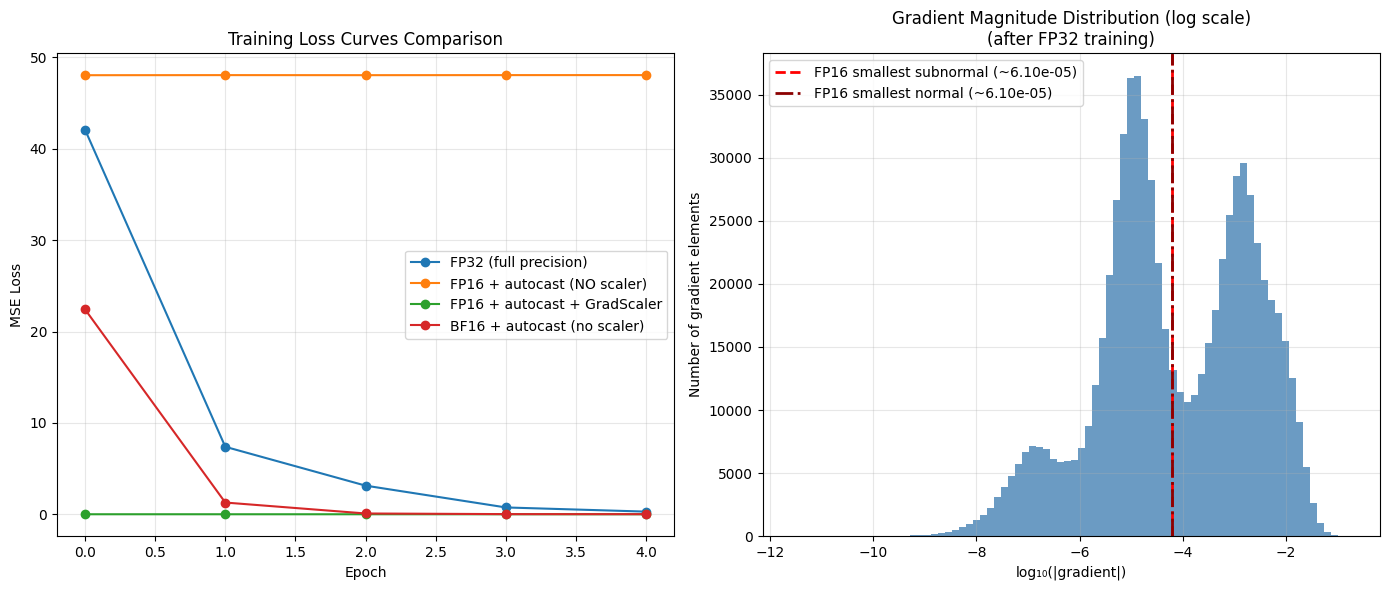

Total gradient elements: 724,481
Gradients smaller than FP16 tiny (6.10e-05): 377,208  (52.066%)
Mean |grad|: 1.84e-03
Max  |grad|: 1.89e-01


In [45]:
import matplotlib.pyplot as plt
import numpy as np

print("\n=== Plotting Results ===")

plt.figure(figsize=(14, 6))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(losses_fp32, label='FP32 (full precision)', marker='o')
plt.plot(losses_no_scale, label='FP16 + autocast (NO scaler)', marker='o')
plt.plot(losses_fp16, label='FP16 + autocast + GradScaler', marker='o')
plt.plot(losses_bf16, label='BF16 + autocast (no scaler)', marker='o')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curves Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# === Fixed Gradient Histogram ===
plt.subplot(1, 2, 2)

# Re-compute gradients properly on one of the trained models (use FP32 version)
model_fp32.train()                    # Important: switch back to train mode
model_fp32.zero_grad()                # Clear any old gradients

# Forward + loss (NO torch.no_grad!)
output = model_fp32(xt[:512])
loss = nn.MSELoss()(output, yt[:512])

loss.backward()                       # Now this will work

# Collect absolute gradient values from all parameters
grad_values = []
for name, param in model_fp32.named_parameters():
    if param.grad is not None:
        grad_values.append(param.grad.abs().view(-1).cpu().numpy())

all_grads = np.concatenate(grad_values)

# Plot histogram on log scale
valid_grads = all_grads[all_grads > 1e-40]   # avoid log(0)
plt.hist(np.log10(valid_grads), bins=80, alpha=0.8, color='steelblue')

# Mark important FP16 thresholds
fp16_tiny = torch.finfo(torch.float16).tiny
fp16_smallest_normal = torch.finfo(torch.float16).smallest_normal

plt.axvline(np.log10(fp16_tiny), color='red', linestyle='--', linewidth=2,
            label=f'FP16 smallest subnormal (~{fp16_tiny:.2e})')
plt.axvline(np.log10(fp16_smallest_normal), color='darkred', linestyle='-.', linewidth=2,
            label=f'FP16 smallest normal (~{fp16_smallest_normal:.2e})')

plt.xlabel('log₁₀(|gradient|)')
plt.ylabel('Number of gradient elements')
plt.title('Gradient Magnitude Distribution (log scale)\n(after FP32 training)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print some useful statistics
print(f"Total gradient elements: {len(all_grads):,}")
print(f"Gradients smaller than FP16 tiny ({fp16_tiny:.2e}): "
      f"{(all_grads < fp16_tiny).sum():,}  ({(all_grads < fp16_tiny).mean():.3%})")
print(f"Mean |grad|: {all_grads.mean():.2e}")
print(f"Max  |grad|: {all_grads.max():.2e}")